In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:

device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
import pandas as pd 
df= pd.read_csv("ZEEL.NS_stock_data.csv")

In [4]:
df.shape

(5430, 8)

In [5]:
df.head()

,Unnamed: 0,open,high,low,close,adjclose,volume,ticker
0,2002-07-01,38.847958,39.138096,38.481468,38.878498,32.353092,4031528.0,ZEEL.NS
1,2002-07-02,38.725796,40.115402,38.542549,39.214447,32.632656,14152321.0,ZEEL.NS
2,2002-07-03,39.031200,39.764183,38.863228,39.565666,32.924931,8456844.0,ZEEL.NS
3,2002-07-04,39.871075,40.833111,39.306068,39.535126,32.899509,12745157.0,ZEEL.NS
4,2002-07-05,40.008511,40.008511,39.015930,39.351879,32.747009,6445895.0,ZEEL.NS


In [6]:
df.isnull().sum()

Unnamed: 0     0
open          10
high          10
low           10
close         10
adjclose      10
volume        10
ticker         0
dtype: int64

In [7]:
df=df.sort_values(df.columns[0]).reset_index(drop=True)

In [8]:
df1=df.iloc[:,1:-1]
df1.shape
df1.head()

,open,high,low,close,adjclose,volume
0,38.847958,39.138096,38.481468,38.878498,32.353092,4031528.0
1,38.725796,40.115402,38.542549,39.214447,32.632656,14152321.0
2,39.031200,39.764183,38.863228,39.565666,32.924931,8456844.0
3,39.871075,40.833111,39.306068,39.535126,32.899509,12745157.0
4,40.008511,40.008511,39.015930,39.351879,32.747009,6445895.0


In [9]:
df1.isnull().sum()

open        10
high        10
low         10
close       10
adjclose    10
volume      10
dtype: int64

In [10]:
df1=df1.interpolate(method="linear", limit_direction="both")
df1.isnull().sum()

open        0
high        0
low         0
close       0
adjclose    0
volume      0
dtype: int64

In [11]:
f_name=df1.columns

print(f_name)

Index(['open', 'high', 'low', 'close', 'adjclose', 'volume'], dtype='str')


<function matplotlib.pyplot.show(close=None, block=None)>

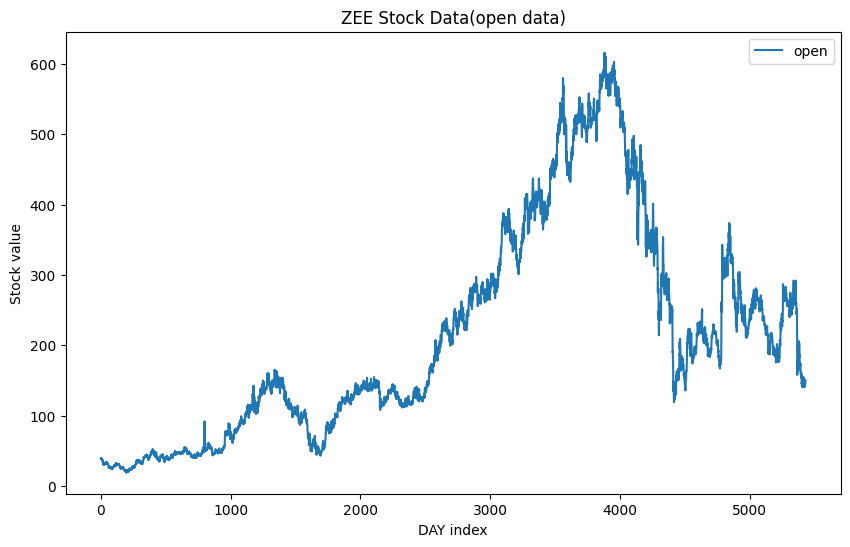

In [12]:
plt.figure(figsize=(10,6))
plt.plot(df1.index, df1[f_name[0]], label=f_name[0])
plt.title('ZEE Stock Data(open data)')
plt.xlabel('DAY index')
plt.ylabel('Stock value')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

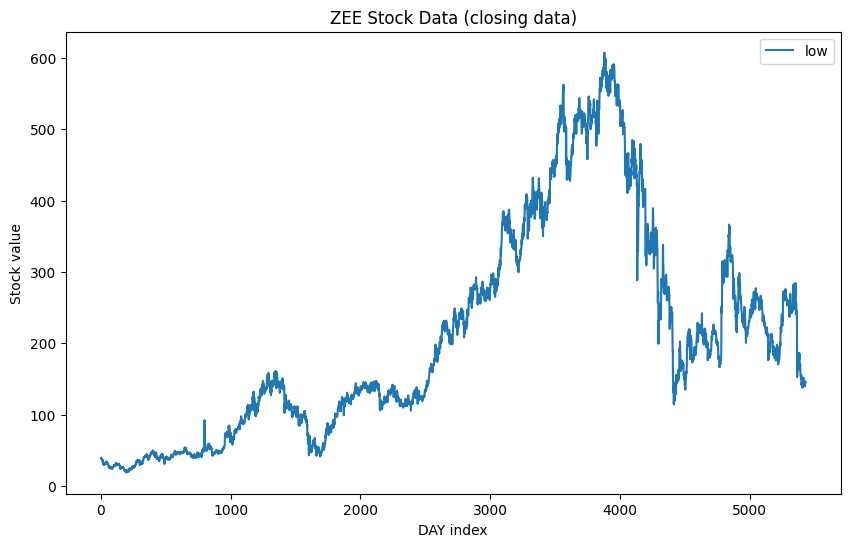

In [13]:
plt.figure(figsize=(10,6))
plt.plot(df1.index, df1[f_name[2]], label=f_name[2])
plt.title('ZEE Stock Data (closing data)')
plt.xlabel('DAY index')
plt.ylabel('Stock value')
plt.legend()
plt.show

In [14]:
data=df1.values.astype(np.float32)
print(data.shape)

(5430, 6)


In [15]:
input_step=10
output_step=5
train_ratio=0.8
batch_size=4

In [16]:
len(data)

5430

In [17]:
split_idx=int(len(data)*train_ratio)
print(split_idx)

4344


In [18]:
train_data1=data[:split_idx]
test_data=data[split_idx:]

In [19]:
split_idx2=int(len(train_data1)*0.8)

In [20]:
train_data=train_data1[:split_idx2]
val_data=train_data1[split_idx2:]


In [21]:
train_data.shape

(3475, 6)

In [22]:
test_data.shape

(1086, 6)

In [23]:
val_data.shape

(869, 6)

In [24]:
from sklearn.preprocessing import normalize
train_data_norm= normalize(train_data, norm='l2', axis=0)
test_data_norm=normalize(test_data, norm='l2', axis=0)
val_data_norm=normalize(val_data, norm='l2', axis=0)

In [25]:
def create_sequences(data_array, input_step=10, output_step=5, overlap=2):
    x,y=[],[]
    total_len=len(data_array)
    stride=input_step-overlap
    if stride<=0:
        raise ValueError("overlap must be smaller than input step")
    for i in range(0, total_len-input_step-output_step+1, stride):
        x.append(data_array[i:i+input_step])
        y.append(data_array[i+input_step: i+input_step+output_step])
    return np.array(x, dtype=np.float32), np.array(y, dtype=np.float32)

In [26]:
x_train, y_train= create_sequences(train_data_norm, input_step,output_step, overlap=8)
x_test, y_test=create_sequences(test_data_norm,input_step,output_step,overlap=8)
x_val, y_val=create_sequences(val_data_norm, input_step, output_step, overlap=8)

In [27]:
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)

x_train: (1731, 10, 6)
y_train: (1731, 5, 6)
x_test: (536, 10, 6)
y_test: (536, 5, 6)
x_val: (428, 10, 6)
y_val: (428, 5, 6)


In [28]:
class TimeSeriesDataset(Dataset):
    def __init__(self,x,y):
        self.x=torch.tensor(x,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.float32)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, index):
        return self.x[index], self.y[index]


In [29]:
train_dataset=TimeSeriesDataset(x_train,y_train)
test_dataset=TimeSeriesDataset(x_test, y_test)
val_dataset=TimeSeriesDataset(x_val,y_val)

train_loader=DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=4, shuffle=False)
val_loader=DataLoader(val_dataset, batch_size=4, shuffle=False)

In [30]:
class LSTMForecaster(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm=nn.LSTM(6,10, batch_first=True)
        self.fc=nn.Linear(10,5*6)
    def forward(self,x):
        out,_=self.lstm(x)
        out=self.fc(out[:,-1,:])\
        
        return out.view(-1,5,6)

In [31]:
model=LSTMForecaster().to(device)
lr=0.0001
optimizer= torch.optim.Adam(model.parameters(), lr=lr)
criterion=nn.MSELoss()
scheduler= torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

In [32]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss=0.0
    for x_batch, y_batch in loader:
        x_batch=x_batch.to(device)
        y_batch=y_batch.to(device)

        optimizer.zero_grad()
        preds=model(x_batch)
        loss=criterion(preds,y_batch)
        loss.backward()
        optimizer.step()

        running_loss+= loss.item()*x_batch.size(0)
    return running_loss/len(loader.dataset)

In [33]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(x_batch)
            loss = criterion(preds, y_batch)

            running_loss += loss.item() * x_batch.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    return avg_loss, all_preds.numpy(), all_targets.numpy()

In [34]:
EPOCH=100
patience=5
train_losses=[]
val_losses=[]
best_val_loss=float('inf')
epochs_no_improve=0
for epoch in range(EPOCH):
    train_loss=train_one_epoch(model,train_loader,optimizer,criterion,device)
    val_loss,_,_= evaluate(model, val_loader, criterion,device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch [{epoch+1}/{EPOCH}] | Train Loss: {train_loss:.6f} | val Loss: {val_loss:.6f}")

    if val_loss<best_val_loss:
        best_val_loss=val_loss
        epochs_no_improve=0

        torch.save(model.state_dict(),"best_model.pt")
    else:
        epochs_no_improve+=1
    if epochs_no_improve>=patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch [1/100] | Train Loss: 0.030006 | val Loss: 0.017717
Epoch [2/100] | Train Loss: 0.009308 | val Loss: 0.002373
Epoch [3/100] | Train Loss: 0.000912 | val Loss: 0.000461
Epoch [4/100] | Train Loss: 0.000136 | val Loss: 0.000476
Epoch [5/100] | Train Loss: 0.000112 | val Loss: 0.000470
Epoch [6/100] | Train Loss: 0.000110 | val Loss: 0.000478
Epoch [7/100] | Train Loss: 0.000108 | val Loss: 0.000501
Epoch [8/100] | Train Loss: 0.000106 | val Loss: 0.000442
Epoch [9/100] | Train Loss: 0.000104 | val Loss: 0.000493
Epoch [10/100] | Train Loss: 0.000102 | val Loss: 0.000415
Epoch [11/100] | Train Loss: 0.000100 | val Loss: 0.000452
Epoch [12/100] | Train Loss: 0.000097 | val Loss: 0.000399
Epoch [13/100] | Train Loss: 0.000095 | val Loss: 0.000446
Epoch [14/100] | Train Loss: 0.000093 | val Loss: 0.000440
Epoch [15/100] | Train Loss: 0.000090 | val Loss: 0.000415
Epoch [16/100] | Train Loss: 0.000087 | val Loss: 0.000411
Epoch [17/100] | Train Loss: 0.000084 | val Loss: 0.000348
Epoch 

In [35]:
test_loss,predictions, targets= evaluate(model, test_loader, criterion, device)
print("final test loss", test_loss)

final test loss 0.00011093358927012818


In [36]:
predictions.shape

(536, 5, 6)

In [37]:
predictions

array([[[0.03675473, 0.03359182, 0.04062723, 0.03837444, 0.0364231 ,
         0.00575424],
        [0.03761238, 0.03601088, 0.0378046 , 0.03708283, 0.03925413,
         0.00379919],
        [0.03902064, 0.03905308, 0.03320154, 0.03999061, 0.03758253,
         0.00723259],
        [0.03680288, 0.03915609, 0.03835118, 0.0328969 , 0.03720127,
         0.00787503],
        [0.03529754, 0.03879046, 0.03443858, 0.04081224, 0.03862751,
         0.00223167]],

       [[0.03780619, 0.03481209, 0.0401827 , 0.03842735, 0.03734729,
         0.00386914],
        [0.03785068, 0.03684807, 0.0382374 , 0.03761046, 0.03928247,
         0.00244734],
        [0.03906105, 0.03926916, 0.03490293, 0.03990928, 0.03826658,
         0.00535372],
        [0.03749537, 0.03884002, 0.03839593, 0.03483187, 0.0376673 ,
         0.00557162],
        [0.03624585, 0.03905255, 0.03555094, 0.0403417 , 0.03878733,
         0.0012566 ]],

       [[0.03813686, 0.03576696, 0.03980976, 0.03856371, 0.03771369,
         0.002463

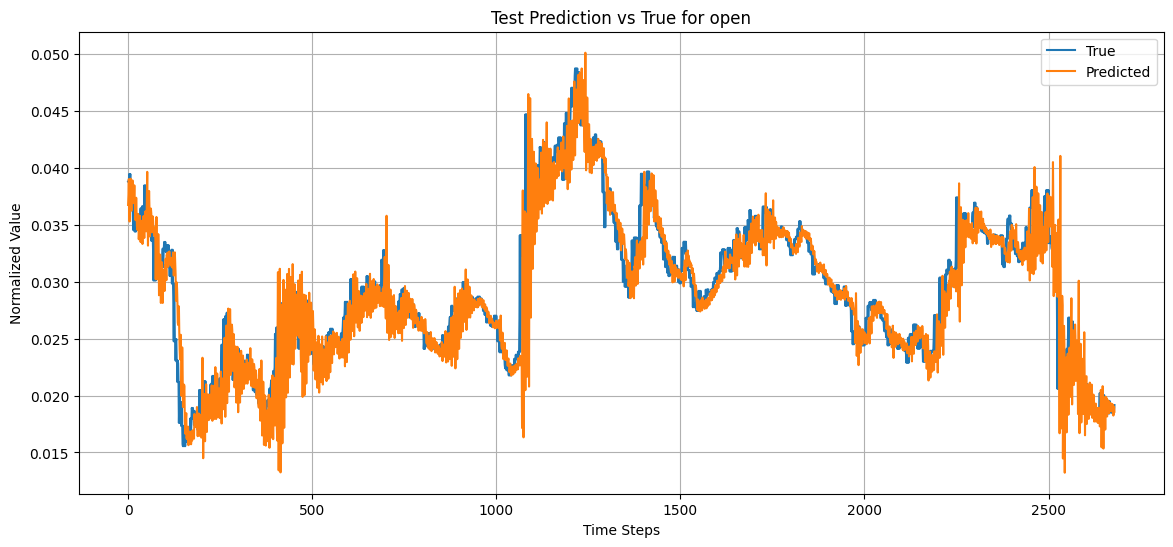

In [38]:
plot_ft = "open"

if plot_ft not in f_name:
    raise ValueError(f"{plot_ft} not found.")

feature_idx = f_name.get_loc(plot_ft)

pred_feature = predictions[:, :, feature_idx].reshape(-1)
true_feature = targets[:, :, feature_idx].reshape(-1)

plt.figure(figsize=(14,6))
plt.plot(true_feature, label="True")
plt.plot(pred_feature, label="Predicted")

plt.title(f"Test Prediction vs True for {plot_ft}")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Value")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = predictions.reshape(-1)
y_true = targets.reshape(-1)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print(f"MSE  : {mse}")
print(f"RMSE : {rmse}")
print(f"MAE  : {mae}")

MSE  : 0.00011093359353253618
RMSE : 0.010532501769880515
MAE  : 0.003850385081022978
